<a href="https://colab.research.google.com/github/vunnampragathi/PhDAI-731/blob/main/Model_Performance_%26_Error_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip -q install imbalanced-learn xgboost scikits-bootstrap

In [10]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_validate,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    make_scorer
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    mutual_info_classif,
    RFE
)

from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN
)

from imblearn.under_sampling import (
    RandomUnderSampler,
    TomekLinks
)

from imblearn.combine import (
    SMOTEENN,
    SMOTETomek
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
!pip -q install kagglehub

In [12]:
import kagglehub
import os
import pandas as pd

In [13]:
dataset_path = kagglehub.dataset_download(
    "ranadeep/credit-risk-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Dataset downloaded to:
/kaggle/input/credit-risk-dataset


In [14]:
csv_files = os.listdir(dataset_path)

# Construct the path to the 'loan' directory where the main data CSV is expected
loan_directory_path = os.path.join(dataset_path, 'loan')

# Construct the full path to the 'loan.csv' file inside the 'loan' directory
csv_path = os.path.join(loan_directory_path, 'loan.csv')

df_raw = pd.read_csv(
    csv_path,
    low_memory=False
)

print("Original Dataset Shape:", df_raw.shape)

# ===========================================
# SAMPLE THE DATASET FOR FASTER EXECUTION
# ===========================================

SAMPLE_SIZE = 20000      # You can change this to 20000, 30000, or 50000

df_raw = df_raw.sample(
    n=SAMPLE_SIZE,
    random_state=42
).reset_index(drop=True)

print("Sampled Dataset Shape:", df_raw.shape)

df_raw.head()

Original Dataset Shape: (887379, 74)
Sampled Dataset Shape: (20000, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,63398958,67740818,8000.0,8000.0,8000.0,36 months,15.61,279.72,D,D1,...,NaN,NaN,NaN,NaN,NaN,NaN,6650.0,NaN,NaN,NaN
1,27610673,30113747,21000.0,21000.0,21000.0,36 months,10.15,679.10,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,14900.0,NaN,NaN,NaN
2,49925091,53293877,19725.0,19725.0,19725.0,36 months,7.89,617.11,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,16200.0,NaN,NaN,NaN
3,28102260,30615399,8000.0,8000.0,8000.0,36 months,15.61,279.72,D,D1,...,NaN,NaN,NaN,NaN,NaN,NaN,15500.0,NaN,NaN,NaN
4,57324697,61027428,35000.0,35000.0,34875.0,36 months,16.99,1247.68,D,D3,...,NaN,NaN,NaN,NaN,NaN,NaN,53600.0,NaN,NaN,NaN


In [15]:
print(os.listdir(dataset_path))

['loan', 'LCDataDictionary.xlsx']


In [16]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

Rows: 20000
Columns: 74


In [17]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 74 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           20000 non-null  int64  
 1   member_id                    20000 non-null  int64  
 2   loan_amnt                    20000 non-null  float64
 3   funded_amnt                  20000 non-null  float64
 4   funded_amnt_inv              20000 non-null  float64
 5   term                         20000 non-null  object 
 6   int_rate                     20000 non-null  float64
 7   installment                  20000 non-null  float64
 8   grade                        20000 non-null  object 
 9   sub_grade                    20000 non-null  object 
 10  emp_title                    18818 non-null  object 
 11  emp_length                   18969 non-null  object 
 12  home_ownership               20000 non-null  object 
 13  annual_inc      

In [18]:
missing_table = pd.DataFrame({
    "Missing Count": df_raw.isnull().sum(),
    "Missing Percentage": df_raw.isnull().mean() * 100
})

missing_table = missing_table.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_table.head(30)

,Missing Count,Missing Percentage
annual_inc_joint,19988,99.940
verification_status_joint,19988,99.940
dti_joint,19988,99.940
il_util,19584,97.920
mths_since_rcnt_il,19541,97.705
inq_fi,19526,97.630
open_rv_24m,19526,97.630
open_acc_6m,19526,97.630
all_util,19526,97.630
inq_last_12m,19526,97.630


In [19]:
df = df_raw.copy()

print(df.shape)

(20000, 74)


Remove columns with too many missing values

In [20]:
missing_percent = df.isnull().mean() * 100

high_missing_cols = missing_percent[
    missing_percent > 80
].index.tolist()

print("Columns removed:")
print(high_missing_cols)

print("Number of columns removed:", len(high_missing_cols))

df.drop(
    columns=high_missing_cols,
    inplace=True
)

print("New dataset shape:", df.shape)

Columns removed:
['desc', 'mths_since_last_record', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
Number of columns removed: 19
New dataset shape: (20000, 55)


Examine loan status

In [21]:
df["loan_status"].value_counts()

,count
loan_status,
Current,13598
Fully Paid,4658
Charged Off,996
Late (31-120 days),267
Issued,187
In Grace Period,149
Late (16-30 days),58
Does not meet the credit policy. Status:Fully Paid,42
Default,23


Create binary target variable

In [22]:
good_status = [
    "Fully Paid",
    "Current",
    "Does not meet the credit policy. Status:Fully Paid"
]

bad_status = [
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Late (16-30 days)",
    "In Grace Period",
    "Does not meet the credit policy. Status:Charged Off"
]

df = df[
    df["loan_status"].isin(
        good_status + bad_status
    )
].copy()

df["default_flag"] = (
    df["loan_status"]
    .isin(bad_status)
    .astype(int)
)

df["default_flag"].value_counts()

,count
default_flag,
0,18298
1,1515


In [23]:
df["default_flag"].value_counts(
    normalize=True
) * 100

,proportion
default_flag,
0,92.353505
1,7.646495


Plot class imbalance

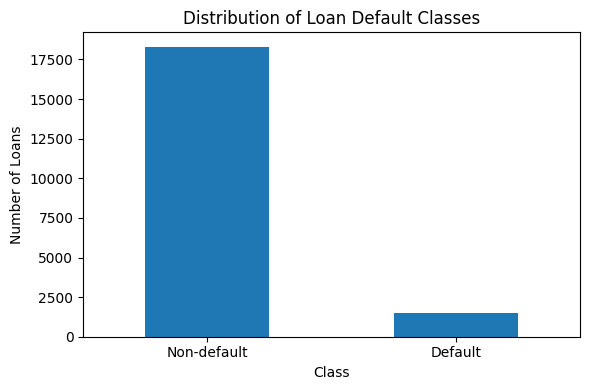

In [24]:
plt.figure(figsize=(6, 4))

df["default_flag"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Loan Default Classes")
plt.xlabel("Class")
plt.ylabel("Number of Loans")
plt.xticks(
    [0, 1],
    ["Non-default", "Default"],
    rotation=0
)

plt.tight_layout()
plt.show()

Remove target leakage columns

In [25]:
leakage_cols = [
    "loan_status",
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d"
]

identifier_cols = [
    "id",
    "member_id",
    "url",
    "desc",
    "title",
    "emp_title",
    "zip_code"
]

columns_to_drop = [
    col
    for col in leakage_cols + identifier_cols
    if col in df.columns
]

df.drop(
    columns=columns_to_drop,
    inplace=True
)

print("Shape after leakage removal:", df.shape)

Shape after leakage removal: (19813, 37)


Convert employment length to numerical values

In [26]:
if "emp_length" in df.columns:
    print(df["emp_length"].value_counts(dropna=False))

emp_length
10+ years    6462
2 years      1711
< 1 year     1663
3 years      1588
1 year       1283
5 years      1235
4 years      1187
NaN          1020
7 years      1007
8 years       989
6 years       915
9 years       753
Name: count, dtype: int64


In [27]:
def convert_emp_length(value):

    if pd.isna(value):
        return np.nan

    value = str(value)

    if "< 1" in value:
        return 0

    if "10+" in value:
        return 10

    match = re.search(r"\d+", value)

    if match:
        return float(match.group())

    return np.nan

In [28]:
if "emp_length" in df.columns:

    df["emp_length_years"] = (
        df["emp_length"]
        .apply(convert_emp_length)
    )

    df.drop(
        columns=["emp_length"],
        inplace=True
    )

df[["emp_length_years"]].head()

,emp_length_years
0,8.0
1,3.0
2,10.0
3,9.0
4,10.0


Convert loan term

In [29]:
if "term" in df.columns:
    print(df["term"].value_counts())

term
36 months    13834
60 months     5979
Name: count, dtype: int64


In [30]:
if "term" in df.columns:

    df["term_months"] = (
        df["term"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(float)
    )

    df.drop(
        columns=["term"],
        inplace=True
    )

Convert interest rate and revolving utilization

Some versions contain % signs.

In [31]:
for column in ["int_rate", "revol_util"]:

    if column in df.columns:

        df[column] = (
            df[column]
            .astype(str)
            .str.replace("%", "", regex=False)
        )

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

Convert date variables

In [32]:
if "issue_d" in df.columns:

    df["issue_date"] = pd.to_datetime(
        df["issue_d"],
        format="%b-%y",
        errors="coerce"
    )

In [33]:
if "earliest_cr_line" in df.columns:

    df["earliest_credit_date"] = pd.to_datetime(
        df["earliest_cr_line"],
        format="%b-%y",
        errors="coerce"
    )

In [34]:
if (
    "issue_date" in df.columns
    and "earliest_credit_date" in df.columns
):

    df["credit_age_years"] = (
        (
            df["issue_date"]
            - df["earliest_credit_date"]
        ).dt.days / 365.25
    )

    df.loc[
        df["credit_age_years"] < 0,
        "credit_age_years"
    ] = np.nan

Create loan-to-income ratio

In [35]:
if (
    "loan_amnt" in df.columns
    and "annual_inc" in df.columns
):

    df["loan_to_income"] = (
        df["loan_amnt"]
        /
        df["annual_inc"].replace(0, np.nan)
    )

Create revolving balance-to-income ratio

In [36]:
if (
    "revol_bal" in df.columns
    and "annual_inc" in df.columns
):

    df["revol_balance_to_income"] = (
        df["revol_bal"]
        /
        df["annual_inc"].replace(0, np.nan)
    )

Create installment burden feature

In [37]:
if (
    "installment" in df.columns
    and "annual_inc" in df.columns
):

    monthly_income = (
        df["annual_inc"] / 12
    )

    df["installment_to_monthly_income"] = (
        df["installment"]
        /
        monthly_income.replace(0, np.nan)
    )

Create interest rate × DTI interaction

In [38]:
if (
    "int_rate" in df.columns
    and "dti" in df.columns
):

    df["interest_x_dti"] = (
        df["int_rate"]
        *
        df["dti"]
    )

Replace infinite values

In [39]:
df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [40]:
print(df.shape)

df.head()

(19813, 44)


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,...,default_flag,emp_length_years,term_months,issue_date,earliest_credit_date,credit_age_years,loan_to_income,revol_balance_to_income,installment_to_monthly_income,interest_x_dti
0,8000.0,8000.0,8000.0,15.61,279.72,D,D1,RENT,78000.0,Verified,...,0,8.0,36.0,NaT,NaT,NaN,0.102564,0.042615,0.043034,401.3331
1,21000.0,21000.0,21000.0,10.15,679.10,B,B2,RENT,81700.0,Source Verified,...,0,3.0,36.0,NaT,NaT,NaN,0.257038,0.140061,0.099745,226.6495
2,19725.0,19725.0,19725.0,7.89,617.11,A,A5,MORTGAGE,78000.0,Not Verified,...,0,10.0,36.0,NaT,NaT,NaN,0.252885,0.157333,0.094940,111.4068
3,8000.0,8000.0,8000.0,15.61,279.72,D,D1,RENT,35000.0,Source Verified,...,0,9.0,36.0,NaT,NaT,NaN,0.228571,0.236714,0.095904,500.6127
4,35000.0,35000.0,34875.0,16.99,1247.68,D,D3,RENT,85000.0,Source Verified,...,0,10.0,36.0,NaT,NaT,NaN,0.411765,0.445306,0.176143,427.9781


Preserve a copy for Time-Series Split

In [41]:
time_df = None

if "issue_date" in df.columns:

    time_df = (
        df
        .dropna(subset=["issue_date"])
        .sort_values("issue_date")
        .copy()
    )

Remove raw date columns from normal modeling

In [42]:
date_columns = [
    "issue_d",
    "issue_date",
    "earliest_credit_date"
]

df.drop(
    columns=[
        c for c in date_columns
        if c in df.columns
    ],
    inplace=True
)

print(df.shape)

(19813, 41)


Separate X and y

In [43]:
X = df.drop(
    columns=["default_flag"]
)

y = df["default_flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19813, 40)
y shape: (19813,)


Train-test split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape)
print("Testing observations:", X_test.shape)

print(
    "Training default percentage:",
    y_train.mean() * 100
)

print(
    "Testing default percentage:",
    y_test.mean() * 100
)

Training observations: (15850, 40)
Testing observations: (3963, 40)
Training default percentage: 7.646687697160884
Testing default percentage: 7.645722937168811


Identify numeric and categorical variables

In [45]:
numeric_cols = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_cols = [
    col
    for col in X_train.columns
    if col not in numeric_cols
]

print(
    "Number of numerical columns:",
    len(numeric_cols)
)

print(
    "Number of categorical columns:",
    len(categorical_cols)
)

Number of numerical columns: 29
Number of categorical columns: 11


Build preprocessing pipeline

Numeric values:

median imputation
standardization

Categorical values:

most frequent imputation
one-hot encoding

In [46]:
numeric_pipeline = SkPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = SkPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_cols
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_cols
        )
    ]
)

Demonstrate multiple imputation

In [47]:
numeric_sample = (
    X_train[numeric_cols]
    .sample(
        min(10000, len(X_train)),
        random_state=42
    )
)

iterative_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

iterative_data = iterative_imputer.fit_transform(
    numeric_sample
)

# Identify columns that were constant in the sample, as IterativeImputer might drop them
constant_cols_in_sample = [
    col for col in numeric_sample.columns
    if numeric_sample[col].nunique(dropna=False) == 1
]

# Filter numeric_cols to match the actual number of columns in iterative_data
# assuming the dropped column(s) are the constant ones.
# This ensures the column names match the data's shape.
actual_numeric_cols = [
    col for col in numeric_cols
    if col not in constant_cols_in_sample
]

# Fallback if the above filtering doesn't result in the correct number of columns
if len(actual_numeric_cols) != iterative_data.shape[1]:
    print("Warning: Number of columns after filtering constant columns still does not match imputer output. Using original numeric_cols for now, but this might indicate another issue.")
    columns_for_df = numeric_cols[:iterative_data.shape[1]] # Take first N columns to match shape
else:
    columns_for_df = actual_numeric_cols

iterative_df = pd.DataFrame(
    iterative_data,
    columns=columns_for_df
)

print("Iterative imputation completed.")

iterative_df.head()

Iterative imputation completed.


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,...,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,emp_length_years,term_months,credit_age_years,loan_to_income,revol_balance_to_income,installment_to_monthly_income
0,20000.0,20000.0,19950.0,6.62,614.08,144000.0,5.80,0.0,0.0,39.799802,...,0.0,0.000000,353124.000000,71400.000000,8.000000,36.0,0.138889,0.186535,0.051173,38.3960
1,6000.0,6000.0,6000.0,19.99,222.96,20000.0,4.50,0.0,2.0,41.000000,...,0.0,999.000000,424.000000,16700.000000,3.000000,36.0,0.300000,0.021200,0.133776,89.9550
2,3000.0,3000.0,3000.0,12.05,99.72,85000.0,11.55,1.0,3.0,7.432623,...,0.0,0.000000,30422.000000,27300.000000,5.846656,36.0,0.035294,0.066965,0.014078,139.1775
3,12000.0,12000.0,12000.0,14.65,413.94,65000.0,14.84,0.0,0.0,38.625675,...,0.0,249.316016,108987.352443,9594.175507,7.000000,36.0,0.184615,0.194492,0.076420,217.4060
4,14975.0,14975.0,14975.0,9.49,479.63,35800.0,24.35,3.0,0.0,15.000000,...,0.0,0.000000,56550.000000,25700.000000,9.000000,36.0,0.418296,0.433911,0.160770,231.0815


Create metric function

In [48]:
def evaluate_model(
    y_true,
    y_pred,
    y_probability
):

    results = {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_probability
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                y_probability
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }

    return results

Logistic Regression baseline

In [49]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'funded_amnt',
                                                   'funded_amnt_inv',
                                                   'int_rate', 'installment',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'mths_since_last_delinq',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revo...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['grade', 'sub_grade',
                                                   'home_ownership',
                                                   'verification_status',
                                                   'pymnt_plan', 'purpose',
                                                   'addr_state',
                                                   'earliest_cr_line',
                                                   'initial_list_status',
                                                   'last_credit_pull_d',
                                                   'application_type'])])),
                ('model', LogisticRegression(max_iter=1500, random_state=42))])

In [50]:
lr_pred = logistic_pipeline.predict(
    X_test
)

lr_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [51]:
lr_results = evaluate_model(
    y_test,
    lr_pred,
    lr_prob
)

lr_results

{'Accuracy': 0.9240474388089831,
 'Balanced Accuracy': np.float64(0.521462965968728),
 'Precision': 0.5384615384615384,
 'Recall': 0.0462046204620462,
 'F1': 0.0851063829787234,
 'ROC-AUC': np.float64(0.7285415426788581),
 'PR-AUC': np.float64(0.22711340470407232),
 'MCC': np.float64(0.14129025475623733)}

Random Forest baseline

In [52]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),

        (
            "model",
            RandomForestClassifier(
                n_estimators=50,
                max_depth=10,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [53]:
rf_pred = rf_pipeline.predict(
    X_test
)

rf_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

In [54]:
rf_results = evaluate_model(
    y_test,
    rf_pred,
    rf_prob
)

rf_results

{'Accuracy': 0.7683573050719152,
 'Balanced Accuracy': np.float64(0.6066912838824866),
 'Precision': 0.1453287197231834,
 'Recall': 0.4158415841584158,
 'F1': 0.2153846153846154,
 'ROC-AUC': np.float64(0.6952469837147649),
 'PR-AUC': np.float64(0.16137604413834747),
 'MCC': np.float64(0.13715472356581526)}

XGBoost baseline

In [55]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=350,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.85,
                colsample_bytree=0.85,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'funded_amnt',
                                                   'funded_amnt_inv',
                                                   'int_rate', 'installment',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'mths_since_last_delinq',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revo...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=350, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [56]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

xgb_prob = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

In [57]:
xgb_results = evaluate_model(
    y_test,
    xgb_pred,
    xgb_prob
)

xgb_results

{'Accuracy': 0.9220287660862982,
 'Balanced Accuracy': np.float64(0.5052345398474274),
 'Precision': 0.2857142857142857,
 'Recall': 0.013201320132013201,
 'F1': 0.025236593059936908,
 'ROC-AUC': np.float64(0.7317192374975203),
 'PR-AUC': np.float64(0.2057895964060081),
 'MCC': np.float64(0.04688811548981568)}

Compare baseline models

In [58]:
baseline_results = pd.DataFrame(
    [
        {
            "Model":
                "Logistic Regression",
            **lr_results
        },
        {
            "Model":
                "Random Forest",
            **rf_results
        },
        {
            "Model":
                "XGBoost",
            **xgb_results
        }
    ]
)

baseline_results = baseline_results.set_index(
    "Model"
)

baseline_results.round(4)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,
Logistic Regression,0.9240,0.5215,0.5385,0.0462,0.0851,0.7285,0.2271,0.1413
Random Forest,0.7684,0.6067,0.1453,0.4158,0.2154,0.6952,0.1614,0.1372
XGBoost,0.9220,0.5052,0.2857,0.0132,0.0252,0.7317,0.2058,0.0469


Set up cross-validation metrics

In [59]:
scoring = {

    "accuracy":
        "accuracy",

    "precision":
        make_scorer(
            precision_score,
            zero_division=0
        ),

    "recall":
        make_scorer(
            recall_score,
            zero_division=0
        ),

    "f1":
        "f1",

    "roc_auc":
        "roc_auc",

    "pr_auc":
        "average_precision"
}

Model for cross-validation

In [60]:
cv_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                random_state=42
            )
        )
    ]
)

Define cross-validation methods

In [61]:
cv_methods = {

    "5-Fold KFold":
        KFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        ),

    "10-Fold KFold":
        KFold(
            n_splits=10,
            shuffle=True,
            random_state=42
        ),

    "5-Fold Stratified":
        StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        ),

    "10-Fold Stratified":
        StratifiedKFold(
            n_splits=10,
            shuffle=True,
            random_state=42
        )
}

Run cross-validation

In [62]:
cv_results_list = []

for name, cv_method in cv_methods.items():

    print(
        "Running:",
        name
    )

    scores = cross_validate(
        cv_model,
        X_train,
        y_train,
        cv=cv_method,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results_list.append({

        "Validation Method":
            name,

        "Accuracy Mean":
            scores[
                "test_accuracy"
            ].mean(),

        "Accuracy SD":
            scores[
                "test_accuracy"
            ].std(),

        "Precision Mean":
            scores[
                "test_precision"
            ].mean(),

        "Recall Mean":
            scores[
                "test_recall"
            ].mean(),

        "F1 Mean":
            scores[
                "test_f1"
            ].mean(),

        "F1 SD":
            scores[
                "test_f1"
            ].std(),

        "ROC-AUC Mean":
            scores[
                "test_roc_auc"
            ].mean(),

        "ROC-AUC SD":
            scores[
                "test_roc_auc"
            ].std(),

        "PR-AUC Mean":
            scores[
                "test_pr_auc"
            ].mean()
    })

Running: 5-Fold KFold
Running: 10-Fold KFold
Running: 5-Fold Stratified
Running: 10-Fold Stratified


In [63]:
cv_results_df = pd.DataFrame(
    cv_results_list
)

cv_results_df.round(4)

,Validation Method,Accuracy Mean,Accuracy SD,Precision Mean,Recall Mean,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD,PR-AUC Mean
0,5-Fold KFold,0.9221,0.0039,0.4077,0.0396,0.0721,0.0126,0.7171,0.0100,0.1895
1,10-Fold KFold,0.9219,0.0062,0.3775,0.0313,0.0572,0.0226,0.7231,0.0189,0.1990
2,5-Fold Stratified,0.9218,0.0016,0.3715,0.0297,0.0548,0.0144,0.7211,0.0242,0.1915
3,10-Fold Stratified,0.9220,0.0024,0.3957,0.0297,0.0546,0.0235,0.7249,0.0277,0.2025


LOOCV

In [64]:
LOOCV_SAMPLE_SIZE = 1000

In [65]:
default_indices = (
    y_train[
        y_train == 1
    ].index
)

nondefault_indices = (
    y_train[
        y_train == 0
    ].index
)

default_rate = y_train.mean()

n_default = int(
    LOOCV_SAMPLE_SIZE
    *
    default_rate
)

n_nondefault = (
    LOOCV_SAMPLE_SIZE
    -
    n_default
)

rng = np.random.default_rng(
    42
)

selected_default = rng.choice(
    default_indices,
    size=n_default,
    replace=False
)

selected_nondefault = rng.choice(
    nondefault_indices,
    size=n_nondefault,
    replace=False
)

selected_indices = np.concatenate(
    [
        selected_default,
        selected_nondefault
    ]
)

In [66]:
X_loocv = X_train.loc[
    selected_indices
]

y_loocv = y_train.loc[
    selected_indices
]

print(X_loocv.shape)

(1000, 40)


In [67]:
loo = LeaveOneOut()

loocv_scores = cross_val_score(
    cv_model,
    X_loocv,
    y_loocv,
    cv=loo,
    scoring="accuracy",
    n_jobs=-1
)

print(
    "LOOCV Accuracy:",
    loocv_scores.mean()
)

print(
    "LOOCV Standard Deviation:",
    loocv_scores.std()
)

LOOCV Accuracy: 0.919
LOOCV Standard Deviation: 0.2728351150420341


Feature selection using Mutual Information

In [68]:
feature_sample_size = min(
    30000,
    len(X_train)
)

X_feature_sample = X_train.sample(
    feature_sample_size,
    random_state=42
)

y_feature_sample = y_train.loc[
    X_feature_sample.index
]

In [69]:
X_feature_encoded = (
    preprocessor.fit_transform(
        X_feature_sample
    )
)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    X_feature_encoded.shape
)

(15850, 771)


In [70]:
mi_scores = mutual_info_classif(
    X_feature_encoded,
    y_feature_sample,
    random_state=42,
    discrete_features="auto"
)

In [71]:
mi_results = pd.DataFrame({

    "Feature":
        feature_names,

    "Mutual Information":
        mi_scores

})

mi_results = mi_results.sort_values(
    "Mutual Information",
    ascending=False
)

mi_results.head(20)

,Feature,Mutual Information
25,numeric__revol_balance_to_income,0.265825
27,numeric__interest_x_dti,0.265337
26,numeric__installment_to_monthly_income,0.263755
12,numeric__revol_bal,0.229269
20,numeric__tot_cur_bal,0.228374
4,numeric__installment,0.192432
24,numeric__loan_to_income,0.121357
6,numeric__dti,0.096908
21,numeric__total_rev_hi_lim,0.046717
5,numeric__annual_inc,0.042540


LASSO-style feature selection

In [72]:
lasso_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=1000,
    random_state=42
)

lasso_model.fit(
    X_feature_encoded,
    y_feature_sample
)

LogisticRegression(C=0.1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [73]:
lasso_results = pd.DataFrame({

    "Feature":
        feature_names,

    "Absolute Coefficient":
        np.abs(
            lasso_model.coef_[0]
        )
})

lasso_results = (
    lasso_results[
        lasso_results[
            "Absolute Coefficient"
        ] > 0
    ]
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
)

lasso_results.head(20)

,Feature,Absolute Coefficient
755,categorical__last_credit_pull_d_Nov-2015,1.303125
724,categorical__last_credit_pull_d_Jan-2016,1.156011
761,categorical__last_credit_pull_d_Oct-2015,0.995602
3,numeric__int_rate,0.520161
690,categorical__initial_list_status_w,0.375524
768,categorical__last_credit_pull_d_Sep-2015,0.277407
70,categorical__home_ownership_MORTGAGE,0.170857
80,categorical__purpose_credit_card,0.138564
46,categorical__sub_grade_C2,0.138324
85,categorical__purpose_major_purchase,0.112514


RFE feature selection

In [74]:
top_30_indices = np.argsort(
    mi_scores
)[::-1][:30]

X_rfe = X_feature_encoded[
    :,
    top_30_indices
]

top_30_names = np.array(
    feature_names
)[top_30_indices]

In [75]:
rfe_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=15
)

rfe.fit(
    X_rfe,
    y_feature_sample
)

RFE(estimator=LogisticRegression(max_iter=1000, solver='liblinear'),
    n_features_to_select=15)

In [76]:
selected_rfe_features = (
    top_30_names[
        rfe.support_
    ]
)

print(
    "Selected RFE features:"
)

for feature in selected_rfe_features:
    print(feature)

Selected RFE features:
numeric__tot_cur_bal
numeric__dti
numeric__funded_amnt_inv
numeric__int_rate
numeric__funded_amnt
numeric__loan_amnt
categorical__last_credit_pull_d_Jan-2016
categorical__initial_list_status_w
categorical__initial_list_status_f
categorical__grade_F
categorical__last_credit_pull_d_Dec-2015
categorical__verification_status_Verified
categorical__grade_D
categorical__grade_B
categorical__grade_E


Define resampling methods

In [77]:
resampling_methods = {

    "No Resampling":
        None,

    "Random Oversampling":
        RandomOverSampler(
            random_state=42
        ),

    "Random Undersampling":
        RandomUnderSampler(
            random_state=42
        ),

    "SMOTE":
        SMOTE(
            random_state=42
        ),

    "ADASYN":
        ADASYN(
            random_state=42
        ),

    "Tomek Links":
        TomekLinks(),

    "SMOTE-ENN":
        SMOTEENN(
            random_state=42
        ),

    "SMOTE-Tomek":
        SMOTETomek(
            random_state=42
        )
}

Compare resampling methods

In [78]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

resampling_results = []

resampling_models = {}

for name, sampler in resampling_methods.items():

    print(
        "Running:",
        name
    )

    steps = [
        (
            "preprocessing",
            preprocessor
        )
    ]

    if sampler is not None:

        steps.append(
            (
                "sampling",
                sampler
            )
        )

    steps.append(
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                random_state=42
            )
        )
    )

    model = ImblearnPipeline(
        steps=steps
    )

    start_time = time.time()

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    metrics = evaluate_model(
        y_test,
        predictions,
        probabilities
    )

    metrics[
        "Resampling Method"
    ] = name

    metrics[
        "Time"
    ] = (
        time.time()
        -
        start_time
    )

    resampling_results.append(
        metrics
    )

    resampling_models[
        name
    ] = model

Running: No Resampling
Running: Random Oversampling
Running: Random Undersampling
Running: SMOTE
Running: ADASYN
Running: Tomek Links
Running: SMOTE-ENN
Running: SMOTE-Tomek


In [79]:
resampling_df = pd.DataFrame(
    resampling_results
)

resampling_df = (
    resampling_df
    .set_index(
        "Resampling Method"
    )
    .sort_values(
        "F1",
        ascending=False
    )
)

resampling_df.round(4)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC,Time
Resampling Method,,,,,,,,,
Random Oversampling,0.7146,0.6578,0.1509,0.5908,0.2404,0.7209,0.2153,0.1831,2.3486
SMOTE,0.7227,0.6455,0.1484,0.5545,0.2341,0.7145,0.2102,0.1712,3.2346
SMOTE-Tomek,0.7227,0.6455,0.1484,0.5545,0.2341,0.7145,0.2102,0.1712,135.7737
ADASYN,0.7181,0.6431,0.1461,0.5545,0.2312,0.7115,0.2066,0.1675,4.6534
Random Undersampling,0.6616,0.6579,0.1381,0.6535,0.2280,0.7152,0.1987,0.1746,0.8432
SMOTE-ENN,0.5276,0.6550,0.1186,0.8053,0.2068,0.7213,0.2043,0.1648,124.1820
No Resampling,0.9240,0.5215,0.5385,0.0462,0.0851,0.7285,0.2271,0.1413,0.6278
Tomek Links,0.9238,0.5213,0.5185,0.0462,0.0848,0.7289,0.2263,0.1378,32.8944


Identify best resampling method

In [80]:
best_resampling_method = (
    resampling_df.index[0]
)

print(
    "Best resampling method based on F1:",
    best_resampling_method
)

Best resampling method based on F1: Random Oversampling


Compare final models

In [81]:
final_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1500,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=350,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
}

In [82]:
def get_sampler(name):

    if name == "Random Oversampling":
        return RandomOverSampler(
            random_state=42
        )

    if name == "Random Undersampling":
        return RandomUnderSampler(
            random_state=42
        )

    if name == "SMOTE":
        return SMOTE(
            random_state=42
        )


    return None

In [83]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

final_results = []

final_model_objects = {}

for name, estimator in final_models.items():

    print(
        "Training:",
        name
    )

    steps = [
        (
            "preprocessing",
            preprocessor
        )
    ]

    sampler = get_sampler(
        best_resampling_method
    )

    if sampler is not None:

        steps.append(
            (
                "sampling",
                sampler
            )
        )

    steps.append(
        (
            "model",
            estimator
        )
    )

    model = ImblearnPipeline(
        steps=steps
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    metrics = evaluate_model(
        y_test,
        predictions,
        probabilities
    )

    metrics["Model"] = name

    final_results.append(
        metrics
    )

    final_model_objects[
        name
    ] = model

Training: Logistic Regression
Training: Random Forest
Training: XGBoost


In [84]:
final_results_df = pd.DataFrame(
    final_results
)

final_results_df = (
    final_results_df
    .set_index("Model")
    .sort_values(
        ["F1", "PR-AUC"],
        ascending=False
    )
)

final_results_df.round(4)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,
XGBoost,0.7858,0.6540,0.1781,0.4983,0.2624,0.7246,0.2121,0.1995
Logistic Regression,0.7146,0.6578,0.1509,0.5908,0.2404,0.7209,0.2153,0.1831
Random Forest,0.9198,0.5085,0.2414,0.0231,0.0422,0.7191,0.1772,0.0533


Select final model

In [85]:
best_model_name = (
    final_results_df.index[0]
)

best_model = (
    final_model_objects[
        best_model_name
    ]
)

print(
    "Final selected model:",
    best_model_name
)

Final selected model: XGBoost


Final predictions

In [86]:
final_predictions = (
    best_model.predict(
        X_test
    )
)

final_probabilities = (
    best_model.predict_proba(
        X_test
    )[:, 1]
)

Classification report

In [87]:
print(
    classification_report(
        y_test,
        final_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9512    0.8096    0.8747      3660
           1     0.1781    0.4983    0.2624       303

    accuracy                         0.7858      3963
   macro avg     0.5646    0.6540    0.5685      3963
weighted avg     0.8921    0.7858    0.8279      3963



Confusion matrix

In [88]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

cm

array([[2963,  697],
       [ 152,  151]])

In [89]:
tn, fp, fn, tp = cm.ravel()

print(
    "True Negatives:",
    tn
)

print(
    "False Positives:",
    fp
)

print(
    "False Negatives:",
    fn
)

print(
    "True Positives:",
    tp
)

True Negatives: 2963
False Positives: 697
False Negatives: 152
True Positives: 151


Plot confusion matrix

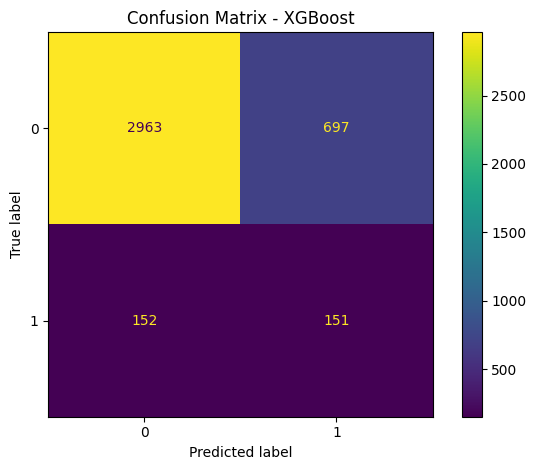

In [90]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()

plt.show()

ROC curve

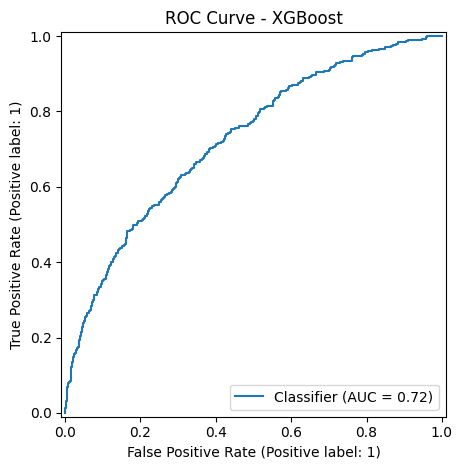

In [91]:
RocCurveDisplay.from_predictions(
    y_test,
    final_probabilities
)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.tight_layout()

plt.show()

Precision-Recall curve

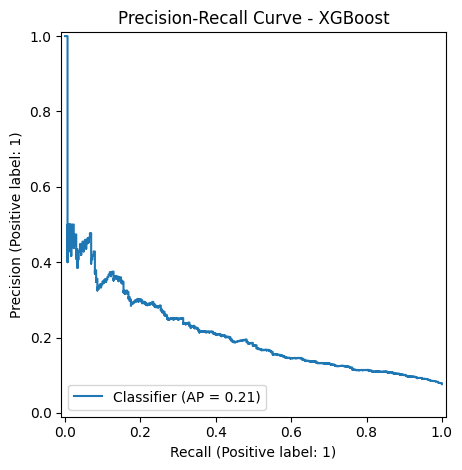

In [92]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    final_probabilities
)

plt.title(
    f"Precision-Recall Curve - {best_model_name}"
)

plt.tight_layout()

plt.show()

Identify false negatives and false positives

Create an error-analysis dataset.

In [93]:
error_analysis = X_test.copy()

error_analysis[
    "Actual"
] = y_test

error_analysis[
    "Predicted"
] = final_predictions

error_analysis[
    "Default Probability"
] = final_probabilities

In [94]:
error_analysis[
    "Error Type"
] = np.where(

    (
        error_analysis["Actual"] == 1
    )
    &
    (
        error_analysis["Predicted"] == 0
    ),

    "False Negative",

    np.where(

        (
            error_analysis["Actual"] == 0
        )
        &
        (
            error_analysis["Predicted"] == 1
        ),

        "False Positive",

        "Correct"
    )
)

In [95]:
false_negatives = error_analysis[
    error_analysis[
        "Error Type"
    ] == "False Negative"
]

print(
    "Number of false negatives:",
    len(false_negatives)
)

false_negatives.head(10)

Number of false negatives: 152


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,...,term_months,credit_age_years,loan_to_income,revol_balance_to_income,installment_to_monthly_income,interest_x_dti,Actual,Predicted,Default Probability,Error Type
17498,20000.0,20000.0,19975.0,17.57,718.75,D,D4,RENT,72000.0,Verified,...,36.0,NaN,0.277778,0.048486,0.119792,224.3689,1,0,0.490568,False Negative
117,5000.0,5000.0,5000.0,16.24,176.38,C,C5,MORTGAGE,28000.0,Not Verified,...,36.0,NaN,0.178571,0.236964,0.075591,117.9024,1,0,0.284110,False Negative
641,20000.0,20000.0,20000.0,12.99,673.79,B,B4,MORTGAGE,119000.0,Source Verified,...,36.0,NaN,0.168067,0.111538,0.067945,190.1736,1,0,0.477536,False Negative
6566,15000.0,15000.0,15000.0,13.33,507.80,C,C3,MORTGAGE,69000.0,Source Verified,...,36.0,NaN,0.217391,0.041725,0.088313,224.2106,1,0,0.362888,False Negative
15830,15000.0,15000.0,15000.0,9.99,318.64,B,B3,MORTGAGE,78000.0,Source Verified,...,60.0,NaN,0.192308,0.318077,0.049022,135.1647,1,0,0.191676,False Negative
12410,8125.0,8125.0,8075.0,14.33,279.00,C,C1,MORTGAGE,24000.0,Verified,...,36.0,NaN,0.338542,0.572208,0.139500,473.6065,1,0,0.408219,False Negative
14446,6000.0,6000.0,6000.0,15.59,209.73,D,D1,RENT,20000.0,Source Verified,...,36.0,NaN,0.300000,0.184450,0.125838,598.9678,1,0,0.292316,False Negative
13369,20000.0,20000.0,20000.0,8.39,630.34,A,A5,MORTGAGE,90000.0,Source Verified,...,36.0,NaN,0.222222,0.203067,0.084045,167.0449,1,0,0.075260,False Negative
15833,20000.0,20000.0,20000.0,21.60,547.84,E,E3,MORTGAGE,70000.0,Verified,...,60.0,NaN,0.285714,0.075157,0.093915,301.7520,1,0,0.212769,False Negative
2085,17625.0,17625.0,17625.0,18.54,641.98,E,E1,MORTGAGE,41000.0,Verified,...,36.0,NaN,0.429878,0.422293,0.187897,650.9394,1,0,0.425357,False Negative


In [96]:
false_positives = error_analysis[
    error_analysis[
        "Error Type"
    ] == "False Positive"
]

print(
    "Number of false positives:",
    len(false_positives)
)

false_positives.head(10)

Number of false positives: 697


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,...,term_months,credit_age_years,loan_to_income,revol_balance_to_income,installment_to_monthly_income,interest_x_dti,Actual,Predicted,Default Probability,Error Type
8978,25000.0,25000.0,25000.0,16.55,885.73,D,D2,MORTGAGE,71438.0,Verified,...,36.0,NaN,0.349954,0.173899,0.148783,140.6750,0,1,0.522933,False Positive
13830,7475.0,7475.0,7475.0,13.11,252.26,B,B4,MORTGAGE,43060.0,Verified,...,36.0,NaN,0.173595,0.217023,0.070300,373.3728,0,1,0.548743,False Positive
13788,8800.0,8800.0,8800.0,12.42,294.06,B,B4,RENT,57000.0,Source Verified,...,36.0,NaN,0.154386,0.157035,0.061907,218.4678,0,1,0.723617,False Positive
7334,10000.0,10000.0,10000.0,13.53,339.50,B,B5,OWN,34000.0,Verified,...,36.0,NaN,0.294118,0.040147,0.119824,127.4526,0,1,0.553677,False Positive
4123,14400.0,14400.0,14400.0,15.22,500.74,C,C3,RENT,49000.0,Not Verified,...,36.0,NaN,0.293878,0.239878,0.122630,418.3978,0,1,0.575372,False Positive
15240,30000.0,30000.0,30000.0,24.99,880.37,F,F4,RENT,86000.0,Verified,...,60.0,NaN,0.348837,0.029791,0.122842,774.9399,0,1,0.903189,False Positive
19147,13750.0,13750.0,13725.0,18.67,354.20,F,F2,RENT,38000.0,Source Verified,...,60.0,NaN,0.361842,0.021263,0.111853,338.6738,0,1,0.814344,False Positive
2615,15000.0,15000.0,15000.0,19.22,390.93,D,D4,MORTGAGE,82000.0,Verified,...,60.0,NaN,0.182927,0.199037,0.057209,351.9182,0,1,0.535372,False Positive
14257,12000.0,12000.0,12000.0,13.80,277.98,C,C4,MORTGAGE,72000.0,Source Verified,...,60.0,NaN,0.166667,0.146472,0.046330,95.9100,0,1,0.503431,False Positive
10974,20000.0,20000.0,20000.0,19.72,526.77,D,D5,RENT,75000.0,Verified,...,60.0,NaN,0.266667,0.210133,0.084283,427.1352,0,1,0.884570,False Positive


Calculate error rates

In [97]:
false_positive_rate = (
    fp /
    (fp + tn)
)

false_negative_rate = (
    fn /
    (fn + tp)
)

print(
    "False Positive Rate:",
    false_positive_rate
)

print(
    "False Negative Rate:",
    false_negative_rate
)

False Positive Rate: 0.19043715846994536
False Negative Rate: 0.5016501650165016


Business-cost threshold analysis

In [98]:
FALSE_NEGATIVE_COST = 5
FALSE_POSITIVE_COST = 1

In [99]:
threshold_results = []

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

for threshold in thresholds:

    threshold_predictions = (
        final_probabilities
        >= threshold
    ).astype(int)

    tn_t, fp_t, fn_t, tp_t = (
        confusion_matrix(
            y_test,
            threshold_predictions
        ).ravel()
    )

    cost = (
        FALSE_NEGATIVE_COST
        *
        fn_t
        +
        FALSE_POSITIVE_COST
        *
        fp_t
    )

    threshold_results.append({

        "Threshold":
            threshold,

        "Precision":
            precision_score(
                y_test,
                threshold_predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                threshold_predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                threshold_predictions,
                zero_division=0
            ),

        "False Positives":
            fp_t,

        "False Negatives":
            fn_t,

        "Business Cost":
            cost
    })

In [100]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.sort_values(
    "Business Cost"
).head(10).round(4)

,Threshold,Precision,Recall,F1,False Positives,False Negatives,Business Cost
12,0.70,0.2846,0.2376,0.2590,181,231,1336
11,0.65,0.2514,0.2871,0.2681,259,216,1339
10,0.60,0.2281,0.3432,0.2740,352,199,1347
13,0.75,0.3036,0.1683,0.2166,117,252,1377
9,0.55,0.2022,0.4257,0.2742,509,174,1379
14,0.80,0.3293,0.0891,0.1403,55,276,1435
8,0.50,0.1781,0.4983,0.2624,697,152,1457
15,0.85,0.4545,0.0495,0.0893,18,288,1458
16,0.90,0.6667,0.0066,0.0131,1,301,1506
7,0.45,0.1551,0.5512,0.2420,910,136,1590


In [101]:
best_threshold = threshold_df.loc[
    threshold_df[
        "Business Cost"
    ].idxmin(),
    "Threshold"
]

print(
    "Best threshold based on business cost:",
    best_threshold
)

Best threshold based on business cost: 0.7000000000000002


Threshold cost graph

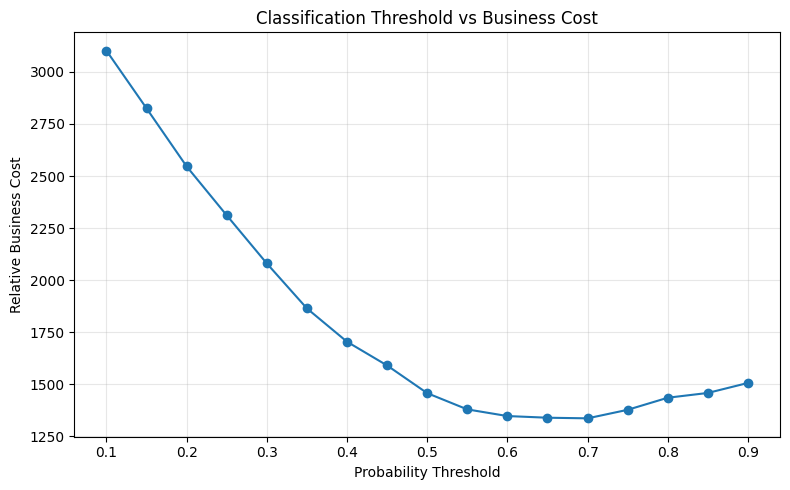

In [102]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_df[
        "Threshold"
    ],
    threshold_df[
        "Business Cost"
    ],
    marker="o"
)

plt.xlabel(
    "Probability Threshold"
)

plt.ylabel(
    "Relative Business Cost"
)

plt.title(
    "Classification Threshold vs Business Cost"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

Feature importance

In [103]:
importance_sample_size = min(
    10000,
    len(X_test)
)

X_importance = X_test.sample(
    importance_sample_size,
    random_state=42
)

y_importance = y_test.loc[
    X_importance.index
]

In [104]:
importance_result = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [105]:
feature_importance_df = pd.DataFrame({

    "Feature":
        X_importance.columns,

    "Importance":
        importance_result
        .importances_mean,

    "Standard Deviation":
        importance_result
        .importances_std
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance_df.head(20)

,Feature,Importance,Standard Deviation
3,int_rate,0.069558,0.014976
24,last_credit_pull_d,0.063147,0.006440
12,addr_state,0.014113,0.002950
31,tot_cur_bal,0.011661,0.002785
39,interest_x_dti,0.009888,0.006574
4,installment,0.008574,0.003126
20,revol_bal,0.007157,0.001969
15,earliest_cr_line,0.006653,0.001613
23,initial_list_status,0.004769,0.001605
11,purpose,0.004269,0.002237


Feature importance graph

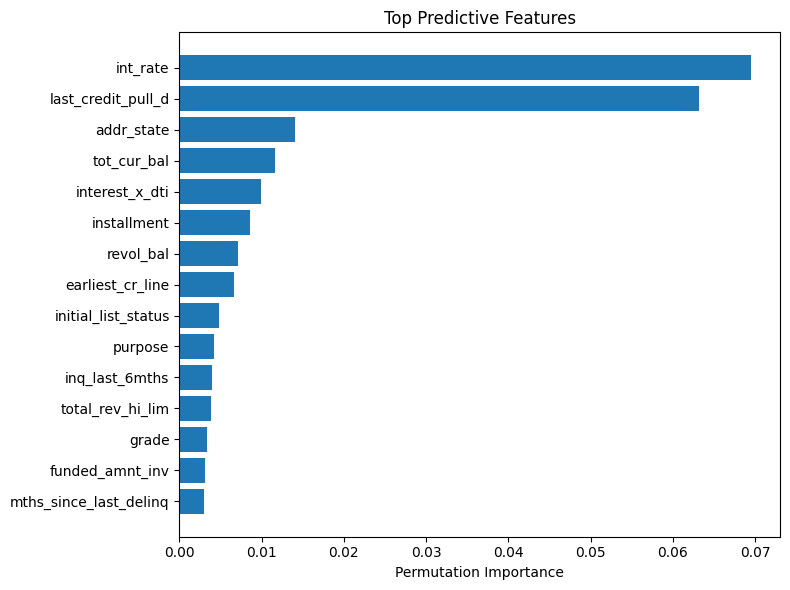

In [106]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    top_features[
        "Feature"
    ],
    top_features[
        "Importance"
    ]
)

plt.xlabel(
    "Permutation Importance"
)

plt.title(
    "Top Predictive Features"
)

plt.tight_layout()

plt.show()

Bootstrap confidence intervals

In [107]:
N_BOOTSTRAPS = 1000

rng = np.random.default_rng(
    42
)

bootstrap_metrics = {

    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "ROC-AUC": [],
    "PR-AUC": []
}

In [108]:
y_true_array = (
    y_test
    .to_numpy()
)

y_pred_array = np.asarray(
    final_predictions
)

y_prob_array = np.asarray(
    final_probabilities
)

n = len(
    y_true_array
)

In [109]:
for i in range(
    N_BOOTSTRAPS
):

    indices = rng.integers(
        0,
        n,
        size=n
    )

    bootstrap_y = (
        y_true_array[
            indices
        ]
    )

    bootstrap_pred = (
        y_pred_array[
            indices
        ]
    )

    bootstrap_prob = (
        y_prob_array[
            indices
        ]
    )

    if (
        len(
            np.unique(
                bootstrap_y
            )
        )
        < 2
    ):
        continue

    bootstrap_metrics[
        "Accuracy"
    ].append(
        accuracy_score(
            bootstrap_y,
            bootstrap_pred
        )
    )

    bootstrap_metrics[
        "Precision"
    ].append(
        precision_score(
            bootstrap_y,
            bootstrap_pred,
            zero_division=0
        )
    )

    bootstrap_metrics[
        "Recall"
    ].append(
        recall_score(
            bootstrap_y,
            bootstrap_pred,
            zero_division=0
        )
    )

    bootstrap_metrics[
        "F1"
    ].append(
        f1_score(
            bootstrap_y,
            bootstrap_pred,
            zero_division=0
        )
    )

    bootstrap_metrics[
        "ROC-AUC"
    ].append(
        roc_auc_score(
            bootstrap_y,
            bootstrap_prob
        )
    )

    bootstrap_metrics[
        "PR-AUC"
    ].append(
        average_precision_score(
            bootstrap_y,
            bootstrap_prob
        )
    )

Calculate 95% bootstrap confidence intervals

In [110]:
bootstrap_ci_results = []

for metric, values in bootstrap_metrics.items():

    values = np.array(
        values
    )

    bootstrap_ci_results.append({

        "Metric":
            metric,

        "Mean":
            values.mean(),

        "Lower 95% CI":
            np.percentile(
                values,
                2.5
            ),

        "Upper 95% CI":
            np.percentile(
                values,
                97.5
            )
    })

In [111]:
bootstrap_ci_df = pd.DataFrame(
    bootstrap_ci_results
)

bootstrap_ci_df.round(4)

,Metric,Mean,Lower 95% CI,Upper 95% CI
0,Accuracy,0.7859,0.7726,0.7986
1,Precision,0.1782,0.1516,0.2047
2,Recall,0.4983,0.4428,0.5526
3,F1,0.2624,0.2273,0.2957
4,ROC-AUC,0.7243,0.6940,0.7530
5,PR-AUC,0.2156,0.1765,0.2605


Bootstrap distribution graph

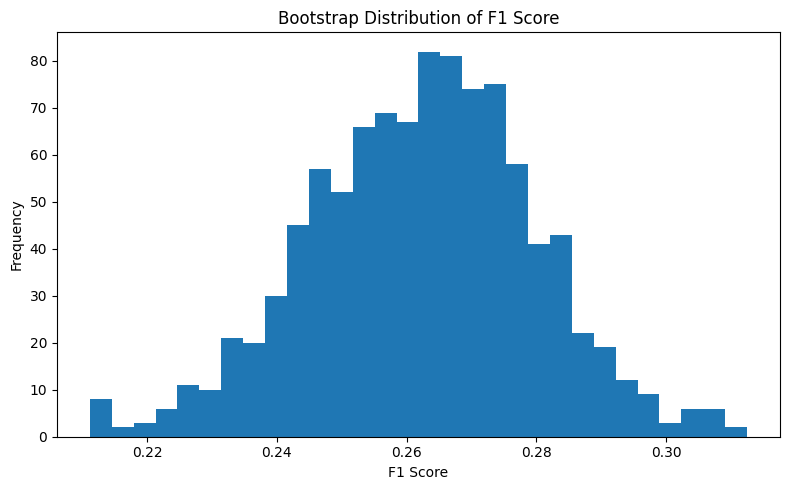

In [112]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    bootstrap_metrics[
        "F1"
    ],
    bins=30
)

plt.xlabel(
    "F1 Score"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Bootstrap Distribution of F1 Score"
)

plt.tight_layout()

plt.show()

Random Forest Out-of-Bag analysis

In [113]:
rf_oob_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                bootstrap=True,
                oob_score=True,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_oob_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'funded_amnt',
                                                   'funded_amnt_inv',
                                                   'int_rate', 'installment',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'mths_since_last_delinq',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revo...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['grade', 'sub_grade',
                                                   'home_ownership',
                                                   'verification_status',
                                                   'pymnt_plan', 'purpose',
                                                   'addr_state',
                                                   'earliest_cr_line',
                                                   'initial_list_status',
                                                   'last_credit_pull_d',
                                                   'application_type'])])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=400,
                                        n_jobs=-1, oob_score=True,
                                        random_state=42))])

In [114]:
rf_oob_model = (
    rf_oob_pipeline
    .named_steps[
        "model"
    ]
)

print(
    "OOB Score:",
    rf_oob_model.oob_score_
)

print(
    "OOB Error:",
    1
    -
    rf_oob_model.oob_score_
)

OOB Score: 0.9235331230283912
OOB Error: 0.07646687697160881


Statistical comparison using paired t-test

We'll compare Logistic Regression and Random Forest ROC-AUC across the same five folds.

In [115]:
stat_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [116]:
stat_lr_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                random_state=42
            )
        )
    ]
)

In [117]:
stat_rf_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [118]:
lr_auc_scores = cross_val_score(
    stat_lr_model,
    X_train,
    y_train,
    cv=stat_cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_auc_scores = cross_val_score(
    stat_rf_model,
    X_train,
    y_train,
    cv=stat_cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [119]:
print(
    "Logistic Regression ROC-AUC:"
)

print(
    lr_auc_scores
)

print(
    "\nRandom Forest ROC-AUC:"
)

print(
    rf_auc_scores
)

Logistic Regression ROC-AUC:
[0.76023602 0.70578879 0.70731298 0.69468029 0.73734677]

Random Forest ROC-AUC:
[0.75116995 0.70399505 0.72843421 0.70208967 0.73005128]


In [120]:
t_statistic, p_value = stats.ttest_rel(
    lr_auc_scores,
    rf_auc_scores
)

print(
    "Paired t-test statistic:",
    t_statistic
)

print(
    "p-value:",
    p_value
)

Paired t-test statistic: -0.3732610111557907
p-value: 0.7278934046230401


In [121]:
baseline_results.to_csv(
    "/content/baseline_model_results.csv"
)

cv_results_df.to_csv(
    "/content/cross_validation_results.csv",
    index=False
)

resampling_df.to_csv(
    "/content/resampling_results.csv"
)

final_results_df.to_csv(
    "/content/final_model_results.csv"
)

bootstrap_ci_df.to_csv(
    "/content/bootstrap_confidence_intervals.csv",
    index=False
)

threshold_df.to_csv(
    "/content/threshold_analysis.csv",
    index=False
)

feature_importance_df.to_csv(
    "/content/feature_importance.csv",
    index=False
)

In [123]:
print(
    "=" * 70
)

print(
    "FINAL CREDIT RISK MODEL RESULTS"
)

print(
    "=" * 70
)

print(
    "\nBest Resampling Method:"
)

print(
    best_resampling_method
)

print(
    "\nBest Final Model:"
)

print(
    best_model_name
)

print(
    "\nFinal Model Performance:"
)

display(
    final_results_df.round(4)
)

print(
    "\nConfusion Matrix:"
)

print(
    cm
)

print(
    "\nFalse Positives:",
    fp
)

print(
    "False Negatives:",
    fn
)

print(
    "\nBest Business Threshold:"
)

print(
    best_threshold
)

print(
    "\nBootstrap Confidence Intervals:"
)

display(
    bootstrap_ci_df.round(4)
)

print(
    "\nPaired t-test:"
)

print(
    "t =",
    round(
        t_statistic,
        4
    )
)

print(
    "p =",
    round(
        p_value,
        6
    )
)

print(
    "\nFeature Importance:"
)

display(
    feature_importance_df.round(4)


)

print(
    "=" * 70
)

FINAL CREDIT RISK MODEL RESULTS

Best Resampling Method:
Random Oversampling

Best Final Model:
XGBoost

Final Model Performance:


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,
XGBoost,0.7858,0.6540,0.1781,0.4983,0.2624,0.7246,0.2121,0.1995
Logistic Regression,0.7146,0.6578,0.1509,0.5908,0.2404,0.7209,0.2153,0.1831
Random Forest,0.9198,0.5085,0.2414,0.0231,0.0422,0.7191,0.1772,0.0533



Confusion Matrix:
[[2963  697]
 [ 152  151]]

False Positives: 697
False Negatives: 152

Best Business Threshold:
0.7000000000000002

Bootstrap Confidence Intervals:


,Metric,Mean,Lower 95% CI,Upper 95% CI
0,Accuracy,0.7859,0.7726,0.7986
1,Precision,0.1782,0.1516,0.2047
2,Recall,0.4983,0.4428,0.5526
3,F1,0.2624,0.2273,0.2957
4,ROC-AUC,0.7243,0.6940,0.7530
5,PR-AUC,0.2156,0.1765,0.2605



Paired t-test:
t = -0.3733
p = 0.727893

Feature Importance:


,Feature,Importance,Standard Deviation
3,int_rate,0.0696,0.0150
24,last_credit_pull_d,0.0631,0.0064
12,addr_state,0.0141,0.0029
31,tot_cur_bal,0.0117,0.0028
39,interest_x_dti,0.0099,0.0066
4,installment,0.0086,0.0031
20,revol_bal,0.0072,0.0020
15,earliest_cr_line,0.0067,0.0016
23,initial_list_status,0.0048,0.0016
11,purpose,0.0043,0.0022
